# Handwritten Digit Recognition - Final Project
CNN + Image Upload Prediction

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
(x_train,y_train),(x_test,y_tkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkklllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllest)=tf.keras.datasets.mnist.load_data()
x_train=x_train/255.0
x_test=x_test/255.0
print('Training samples:',len(x_train))

In [ ]:
plt.figure(figsize=(100,4))
for d in range(10):
 idx=np.where(y_train==d)[0][0]
 plt.subplot(2,5,d+1)
 plt.imshow(x_train[idx],cmap='gray')
 plt.title(str(d))
 plt.axis('off')
plt.show()

In [ ]:
model=tf.keras.Sequential([
tf.keras.layers.Reshape((28,28,1),input_shape=(28,28)),
tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
tf.keras.layers.MaxPooling2D((2,2)),
tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
tf.keras.layers.MaxPooling2D((2,2)),
tf.keras.layers.Flatten(),
tf.keras.layers.Dense(128,activation='relu'),
tf.keras.layers.Dropout(0.3),
tf.keras.layers.Dense(10,activation='softmax')])
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history=model.fit(x_train,y_train,epochs=15,validation_split=0.2)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 52s 34ms/step - accuracy: 0.9446 - loss: 0.1785 - val_accuracy: 0.9842 - val_loss: 0.0532
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 33ms/step - accuracy: 0.9812 - loss: 0.0606 - val_accuracy: 0.9879 - val_loss: 0.0406
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 33ms/step - accuracy: 0.9868 - loss: 0.0422 - val_accuracy: 0.9904 - val_loss: 0.0348
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 33ms/step - accuracy: 0.9895 - loss: 0.0335 - val_accuracy: 0.9896 - val_loss: 0.0362
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 32ms/step - accuracy: 0.9913 - loss: 0.0266 - val_accuracy: 0.9908 - val_loss: 0.0385
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 47s 31ms/step - accuracy: 0.9926 - loss: 0.0230 - val_accuracy: 0.9906 - val_loss: 0.0376
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 85s 33ms/step - accuracy: 0.9942 - loss: 0.0178 - val_accuracy: 0.9907 - val_loss: 0.0370
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 33ms/step - accuracy: 0.9943 -

In [ ]:
loss,acc=model.evaluate(x_test,y_test)
print('Test Accuracy:',acc*100,'%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9940 - loss: 0.0308
Test Accuracy: 99.40000176429749 %


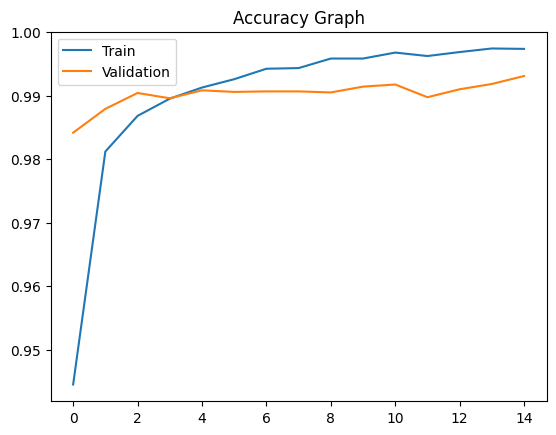

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.title('Accuracy Graph')
plt.show()

In [ ]:
model.save('digit_recognition_model.keras')
print('Model Saved')

Model Saved


## Upload Your Own Digit Image

In [ ]:
from google.colab import files
uploaded=files.upload()
filename=list(uploaded.keys())[0]
img=Image.open(filename).convert('L')
img=np.array(img)
img=255-img
ys,xs=np.where(img>50)
if len(xs)>0:
 img=img[min(ys):max(ys)+1,min(xs):max(xs)+1]
img=Image.fromarray(img).resize((20,20))
img=np.array(img)
canvas=np.zeros((28,28))
canvas[4:24,4:24]=img
img=canvas/255.0
plt.imshow(img,cmap='gray')
plt.axis('off')
plt.show()
pred=model.predict(img.reshape(1,28,28),verbose=0)
digit=np.argmax(pred)
confidence=np.max(pred)*100
print('Predicted Digit:',digit)
print(f'Confidence: {confidence:.2f}%')